## 8.9 경제물리학의 위험 분석을 위한 양자 몬테카를로 방법

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QFT
from qiskit.visualization import plot_histogram, plot_bloch_multivector, plot_state_city
from qiskit_aer import AerSimulator, noise
from qiskit.quantum_info import Statevector, partial_trace
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [2]:
# 양자회로 파라미터 정의
n_qubits = 4  # 금융 변수를 나타내는 큐비트 수
theta_values = np.random.uniform(0, 2 * np.pi, n_qubits)  # 무작위 theta 값 생성

In [3]:
# QMC용 양자회로 생성
qc = QuantumCircuit(n_qubits)

In [4]:
# 얽힘을 가진 금융 변수를 모사하는 양자 게이트 적용
for i in range(n_qubits):
    qc.h(i)  # 중첩으로 초기화
    qc.ry(theta_values[i], i)  # 시장 동역학을 모사하는 회전 게이트

In [5]:
# 제어 게이트로 얽힘 도입
for i in range(n_qubits - 1):
    qc.cx(i, i + 1)  # CNOT 게이트로 큐비트 얽힘

In [6]:
# 위험 분포를 모사하기 위해 양자 푸리에 변환 적용
qc.append(QFT(n_qubits, do_swaps=False), range(n_qubits))

In [7]:
# 역 QFT (완전성을 위해)
qc.append(QFT(n_qubits, do_swaps=False).inverse(), range(n_qubits))

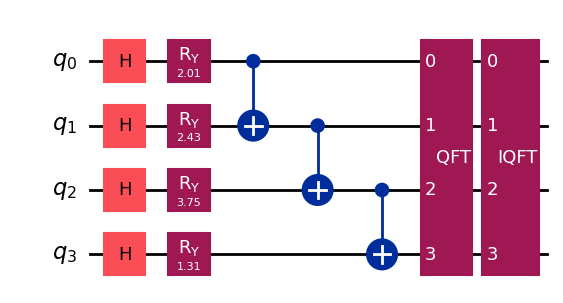

In [8]:
# 회로 시각화
qc.draw('mpl')
plt.show()

In [9]:
# 상태벡터 시뮬레이션 (측정 없이)
statevector = Statevector.from_instruction(qc)

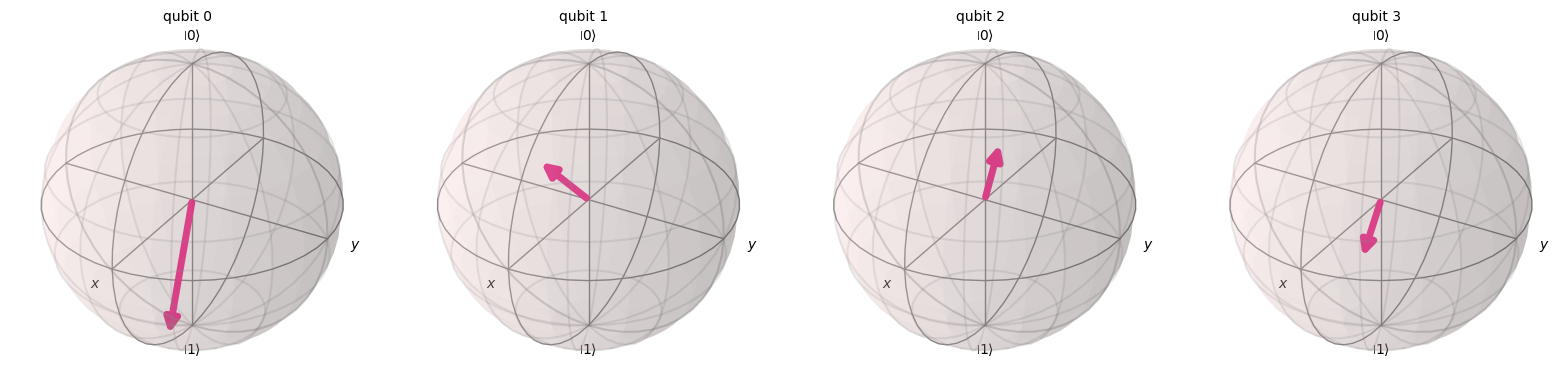

In [10]:
# 최종 상태의 블로흐 구 시각화
plot_bloch_multivector(statevector)
plt.show()

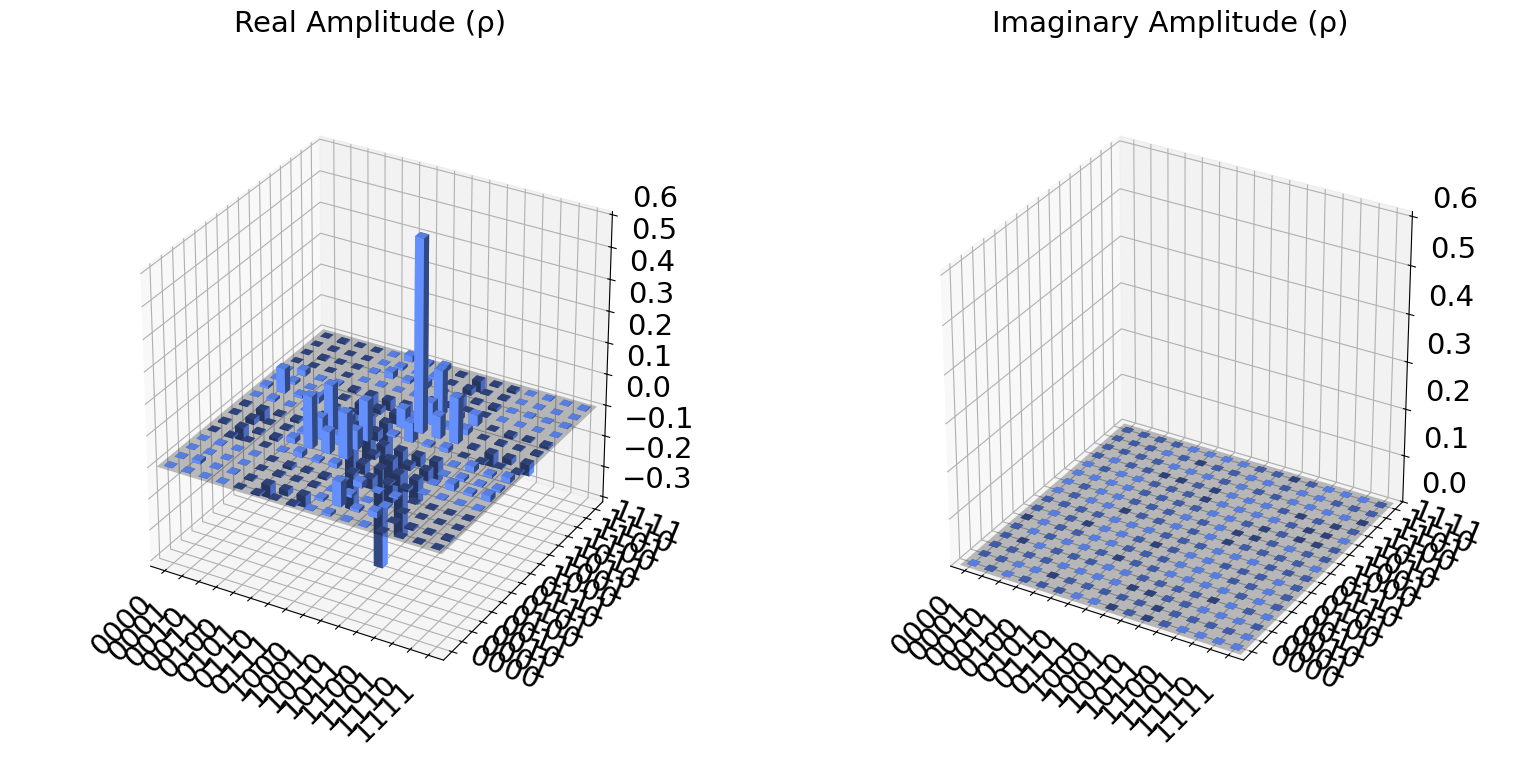

In [11]:
# 고급 시각화: state city 플롯
plot_state_city(statevector)
plt.show()

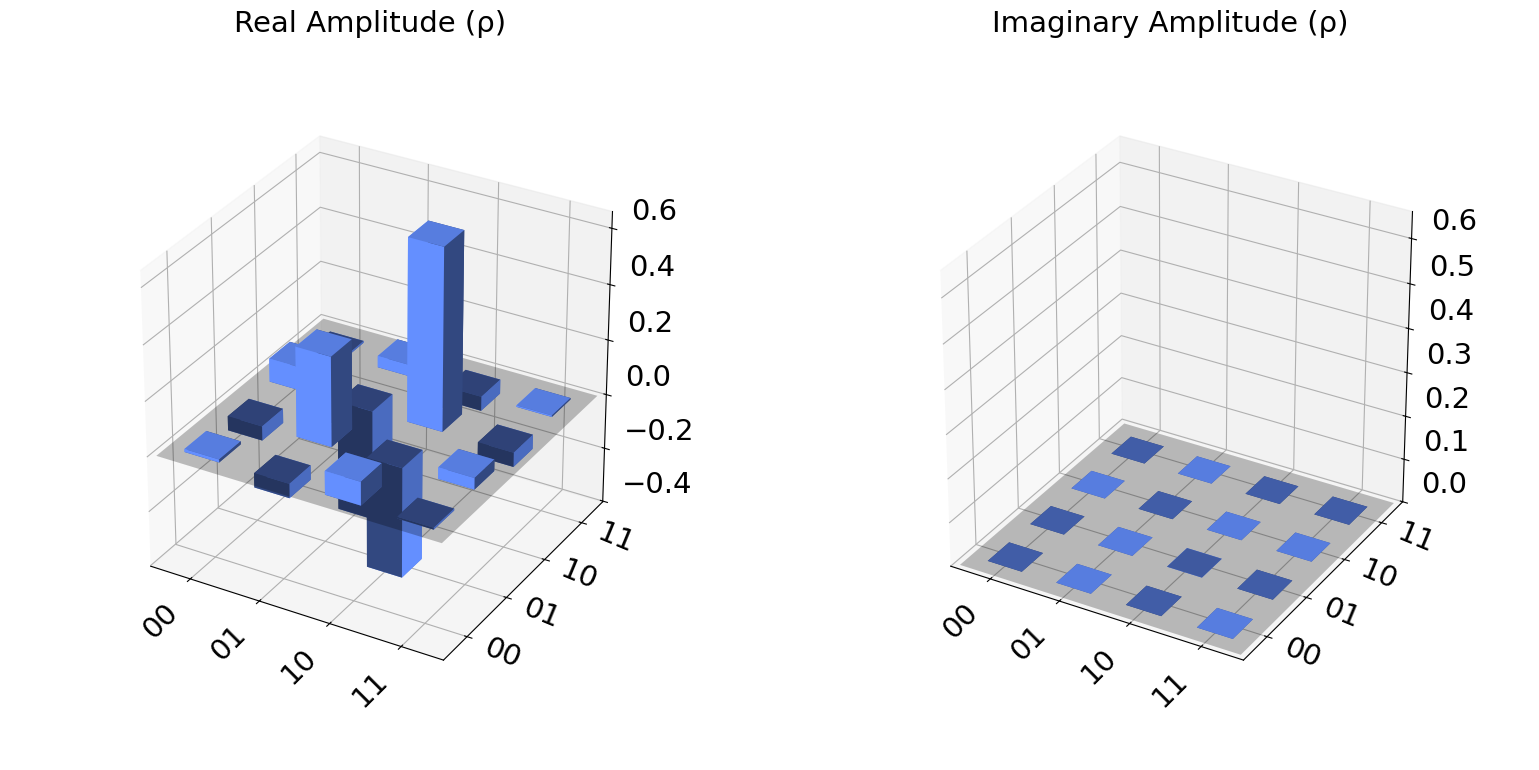

In [12]:
# 부분 대각합으로 부분계 분석 (더 복잡한 경제 분석)
subsystem_trace = partial_trace(statevector, [0, 1])
plot_state_city(subsystem_trace)
plt.show()

In [13]:
# 이제 AerSimulator 최종 시뮬레이션을 위해 측정 추가
qc.measure_all()

In [14]:
# 트랜스파일을 위한 시뮬레이터 초기화
simulator = AerSimulator()

In [15]:
# 시뮬레이터에 현실적인 잡음 모델 추가
noise_model = noise.NoiseModel()
error_rate = 0.01
for qubit in range(n_qubits):
    noise_model.add_all_qubit_quantum_error(noise.depolarizing_error(error_rate, 1), ['ry'])
    noise_model.add_all_qubit_quantum_error(noise.depolarizing_error(error_rate, 2), ['cx'])

qc_transpiled = transpile(qc, simulator)

In [16]:
# 잡음과 측정을 포함해 회로 시뮬레이션
result = simulator.run(qc_transpiled, noise_model=noise_model).result()
counts = result.get_counts()

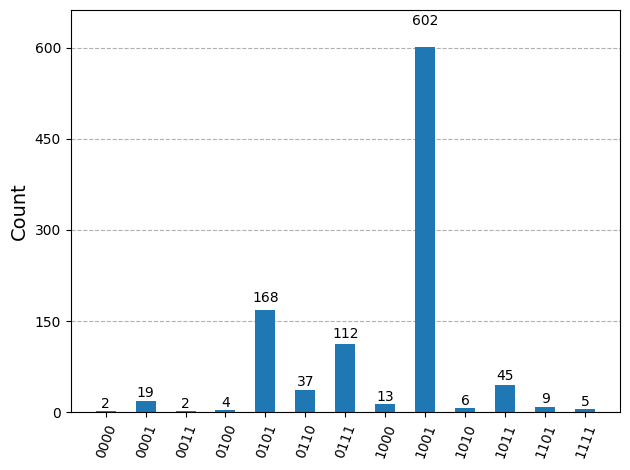

In [17]:
# 결과를 히스토그램으로 표시
plot_histogram(counts)
plt.show()

In [18]:
# 기댓값 또는 위험 지표 계산
expected_value = sum([int(state, 2) * count for state, count in counts.items()]) / sum(counts.values())
print(f'기댓값 (위험 지표): {expected_value}')

기댓값 (위험 지표): 7.96484375


In [19]:
# 더 복잡한 위험 지표: 분산
variance = sum([(int(state, 2) - expected_value) ** 2 * count for state, count in counts.items()]) / sum(counts.values())
print(f'분산 (위험 지표): {variance}')

분산 (위험 지표): 4.3405609130859375
